# Determinantes do Acesso ao Ensino Superior Público Federal no Brasil
### Regressão Logística Multinomial com Microdados do ENADE 2017

**Variável resposta:** Categoria administrativa da IES (CO_CATEGAD)  
**Método:** GLM — Regressão Logística Multinomial (MNLogit)  
**Categoria de referência:** Privada (categorias 4 e 5)  
**Fonte:** INEP — Microdados do ENADE 2017

---
## 0. Dependências

In [21]:
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

---
## 1. Importação dos Dados

Ajuste o caminho `DATA_PATH` para o local onde estão os microdados do ENADE 2017 baixados do INEP.

In [2]:
df_raw = pd.read_parquet('Enade2017.parquet')

---
## 2. Filtros Iniciais e Seleção de Variáveis

In [59]:
# Manter apenas concluintes presentes (TP_PRES == 555)
df = df_raw[df_raw['TP_PRES'] == 555].copy()
print(f'Após filtro de presença: {df.shape[0]:,} observações')

# Colunas do projeto
COLS = [
    # Resposta e estratificação
    'CO_CATEGAD', 'CO_ORGACAD', 'CO_GRUPO', 'CO_MODALIDADE',
    'CO_REGIAO_CURSO', 'CO_UF_CURSO', 'CO_TURNO_GRADUACAO',
    # Perfil individual
    'TP_SEXO', 'NU_IDADE',
    # Questionário socioeconômico
    'QE_I01', 'QE_I02', 'QE_I03', 'QE_I04', 'QE_I05',
    'QE_I06', 'QE_I07', 'QE_I08', 'QE_I09', 'QE_I10',
    'QE_I11', 'QE_I12', 'QE_I13', 'QE_I14', 'QE_I15',
    'QE_I16', 'QE_I17', 'QE_I18', 'QE_I19', 'QE_I20',
    'QE_I21', 'QE_I22', 'QE_I23', 'QE_I24', 'QE_I25', 'QE_I26'
]

df = df[COLS].copy()
print(f'Variáveis selecionadas: {df.shape[1]}')

Após filtro de presença: 450,061 observações
Variáveis selecionadas: 35


---
## 3. Feature Engineering

### 3.1 Variável Resposta (Y)

| Código original | Descrição | Y recodificada |
|---|---|---|
| 1 | Pública Federal | **1** |
| 2 | Pública Estadual | **2** |
| 3 | Pública Municipal | **2** |
| 4 | Privada c/ fins lucrativos | **0** (base) |
| 5 | Privada s/ fins lucrativos | **0** (base) |
| 7 | Especial | removida |

In [60]:
cat_map = {1: 1, 2: 1, 3: 1, 4: 0, 5: 0}
df['Y'] = df['CO_CATEGAD'].map(cat_map)

# Remove categoria especial (7) e missing
df = df[df['Y'].notna()].copy()
df['Y'] = df['Y'].astype(int)

print('Distribuição da variável resposta:')
labels = {0: 'Privada (base)', 1: 'Federal', 2: 'Estadual/Municipal'}
print(df['Y'].map(labels).value_counts())
print()
print(df['Y'].map(labels).value_counts(normalize=True).round(3))

Distribuição da variável resposta:
Y
Privada (base)    286989
Federal           161273
Name: count, dtype: int64

Y
Privada (base)   0.6400
Federal          0.3600
Name: proportion, dtype: float64


### 3.2 Variáveis Ordinais

Variáveis cujas categorias têm progressão natural são convertidas para escala numérica.

In [61]:
ORDINAL_MAPS = {
    # Renda familiar (A=mais baixa → G=mais alta)
    'QE_I08': {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7},

    # Escolaridade do pai (A=nenhuma → F=pós-graduação)
    'QE_I04': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5},

    # Escolaridade da mãe
    'QE_I05': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5},

    # Número de pessoas na família
    'QE_I07': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7},

    # Situação de trabalho (A=não trabalha → E=40h+)
    'QE_I10': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},

    # Livros lidos no ano
    'QE_I22': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},

    # Horas de estudo semanais
    'QE_I23': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4},
}

for col, mapping in ORDINAL_MAPS.items():
    df[col] = df[col].map(mapping)

print('Variáveis ordinais convertidas:', list(ORDINAL_MAPS.keys()))

Variáveis ordinais convertidas: ['QE_I08', 'QE_I04', 'QE_I05', 'QE_I07', 'QE_I10', 'QE_I22', 'QE_I23']


### 3.3 Variáveis Nominais (Dummies)

Variáveis categóricas sem ordem são convertidas em dummies. `drop_first=True` evita multicolinearidade perfeita.

In [62]:
NOMINAL_COLS = [
    'QE_I01',  # Estado civil
    'QE_I02',  # Cor/raça
    'QE_I03',  # Nacionalidade
    'QE_I06',  # Onde mora
    'QE_I09',  # Situação financeira
    'QE_I11',  # Tipo de bolsa/financiamento
    'QE_I12',  # Auxílio permanência
    'QE_I13',  # Bolsa acadêmica
    'QE_I14',  # Intercâmbio
    'QE_I15',  # Cotas/ação afirmativa
    'QE_I17',  # Tipo de escola no EM
    'QE_I18',  # Modalidade do EM
    'QE_I19',  # Quem incentivou
    'QE_I20',  # Apoio para superar dificuldades
    'QE_I21',  # Família com superior
    'QE_I24',  # Idioma estrangeiro na IES
    'QE_I25',  # Motivo para escolher o curso
    'QE_I26',  # Motivo para escolher a IES
    'TP_SEXO',
    'CO_REGIAO_CURSO',
    'CO_TURNO_GRADUACAO',
    'CO_MODALIDADE',
]

df = pd.get_dummies(df, columns=NOMINAL_COLS, drop_first=True, dtype=int)

# Limpeza final — remove linhas com qualquer NA
n_before = len(df)
df = df.dropna()
n_after = len(df)

print(f'Removidas por NA: {n_before - n_after:,} ({(n_before - n_after)/n_before:.1%})')
print(f'Dataset final: {n_after:,} observações | {df.shape[1]} variáveis')

Removidas por NA: 7,020 (1.6%)
Dataset final: 441,242 observações | 119 variáveis


---
## 4. Análise Exploratória (EDA)

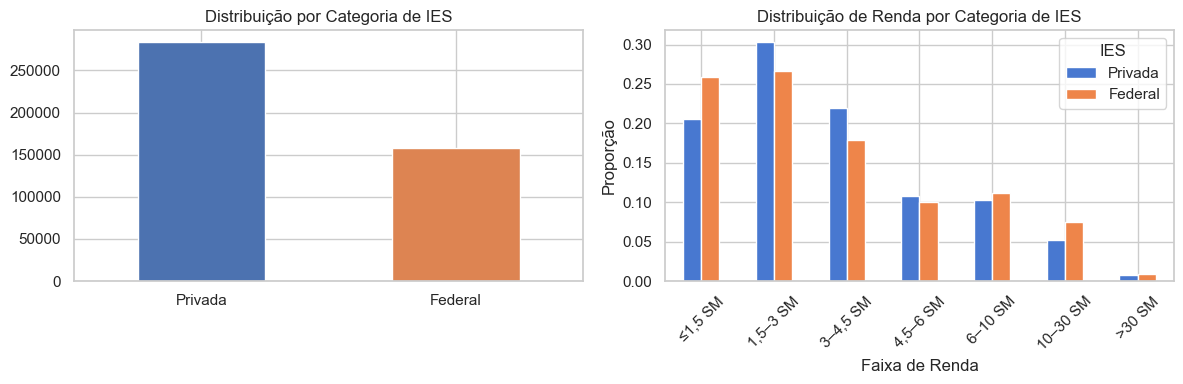

In [63]:
# Distribuição da resposta
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = {0: 'Privada', 1: 'Federal', 2: 'Estadual/\nMunicipal'}
counts = df['Y'].map(labels).value_counts()

counts.plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Distribuição por Categoria de IES')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Renda por categoria de IES
renda_labels = {1:'≤1,5 SM', 2:'1,5–3 SM', 3:'3–4,5 SM',
                4:'4,5–6 SM', 5:'6–10 SM', 6:'10–30 SM', 7:'>30 SM'}

renda_dist = df.groupby('Y')['QE_I08'].value_counts(normalize=True).unstack(fill_value=0)
renda_dist.index = renda_dist.index.map(labels)
renda_dist.columns = renda_dist.columns.map(renda_labels)
renda_dist.T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Distribuição de Renda por Categoria de IES')
axes[1].set_xlabel('Faixa de Renda')
axes[1].set_ylabel('Proporção')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='IES')

plt.tight_layout()
plt.show()

In [66]:
df_raw

,NU_ANO,CO_IES,CO_CATEGAD,CO_ORGACAD,CO_GRUPO,CO_CURSO,CO_MODALIDADE,CO_MUNIC_CURSO,CO_UF_CURSO,CO_REGIAO_CURSO,NU_IDADE,TP_SEXO,ANO_FIM_EM,ANO_IN_GRAD,CO_TURNO_GRADUACAO,TP_INSCRICAO_ADM,TP_INSCRICAO,NU_ITEM_OFG,NU_ITEM_OFG_Z,NU_ITEM_OFG_X,NU_ITEM_OFG_N,NU_ITEM_OCE,NU_ITEM_OCE_Z,NU_ITEM_OCE_X,NU_ITEM_OCE_N,DS_VT_GAB_OFG_ORIG,DS_VT_GAB_OFG_FIN,DS_VT_GAB_OCE_ORIG,DS_VT_GAB_OCE_FIN,DS_VT_ESC_OFG,DS_VT_ACE_OFG,DS_VT_ESC_OCE,DS_VT_ACE_OCE,TP_PRES,TP_PR_GER,TP_PR_OB_FG,TP_PR_DI_FG,TP_PR_OB_CE,TP_PR_DI_CE,TP_SFG_D1,TP_SFG_D2,TP_SCE_D1,TP_SCE_D2,TP_SCE_D3,NT_GER,NT_FG,NT_OBJ_FG,NT_DIS_FG,NT_FG_D1,NT_FG_D1_PT,NT_FG_D1_CT,NT_FG_D2,NT_FG_D2_PT,NT_FG_D2_CT,NT_CE,NT_OBJ_CE,NT_DIS_CE,NT_CE_D1,NT_CE_D2,NT_CE_D3,CO_RS_I1,CO_RS_I2,CO_RS_I3,CO_RS_I4,CO_RS_I5,CO_RS_I6,CO_RS_I7,CO_RS_I8,CO_RS_I9,QE_I01,QE_I02,QE_I03,QE_I04,QE_I05,QE_I06,QE_I07,QE_I08,QE_I09,QE_I10,QE_I11,QE_I12,QE_I13,QE_I14,QE_I15,QE_I16,QE_I17,QE_I18,QE_I19,QE_I20,QE_I21,QE_I22,QE_I23,QE_I24,QE_I25,QE_I26,QE_I27,QE_I28,QE_I29,QE_I30,QE_I31,QE_I32,QE_I33,QE_I34,QE_I35,QE_I36,QE_I37,QE_I38,QE_I39,QE_I40,QE_I41,QE_I42,QE_I43,QE_I44,QE_I45,QE_I46,QE_I47,QE_I48,QE_I49,QE_I50,QE_I51,QE_I52,QE_I53,QE_I54,QE_I55,QE_I56,QE_I57,QE_I58,QE_I59,QE_I60,QE_I61,QE_I62,QE_I63,QE_I64,QE_I65,QE_I66,QE_I67,QE_I68,QE_I69,QE_I70,QE_I71,QE_I72,QE_I73,QE_I74,QE_I75,QE_I76,QE_I77,QE_I78,QE_I79,QE_I80,QE_I81
0,2017,1,1,10028,5710,3,1,5103403,51,5,26,F,2007.0000,2012.0000,3.0000,0,1,8,0,0,0,27,0,8,0,CCBBCEAD,CCBBCEAD,EDCAEABCDBDDDCBCBBEADDCBEDB,EDXXEABCXBXDDCXCXBEADXCBEXB,DCBBCEAD,01111111,EEEADDBCABADCCAAAEEDDDCAACB,109900119191019090101910091,555.0000,555.0000,555.0000,555.0000,555.0000,555.0000,555.0000,333.0000,555.0000,555.0000,333.0000,"52,6","64,1","87,5","29,0",58.0000,50.0000,60.0000,0.0000,0.0000,0.0000,"48,7","52,6","26,7",55.0000,25.0000,0.0000,C,D,D,B,C,C,B,D,C,A,A,A,D,F,A,A,B,C,B,A,A,A,A,A,51.0000,B,A,B,H,A,B,D,E,H,I,5.0000,5.0000,4.0000,3.0000,3.0000,4.0000,3.0000,5.0000,3.0000,5.0000,2.0000,2.0000,3.0000,1.0000,1.0000,5.0000,1.0000,2.0000,2.0000,2.0000,1.0000,2.0000,2.0000,5.0000,5.0000,2.0000,3.0000,1.0000,3.0000,3.0000,4.0000,3.0000,3.0000,5.0000,3.0000,2.0000,2.0000,2.0000,1.0000,4.0000,4.0000,3.0000,None,None,None,None,None,None,None,None,None,None,None,None,None
1,2017,1,1,10028,5710,3,1,5103403,51,5,23,F,2013.0000,2013.0000,3.0000,0,1,8,0,0,0,27,0,8,0,CCBBCEAD,CCBBCEAD,EDCAEABCDBDDDCBCBBEADDCBEDB,EDXXEABCXBXDDCXCXBEADXCBEXB,CCBBCEBD,11111101,ECDEAADCABADDCDEAADCDCCBECB,109901019191119090001911191,555.0000,555.0000,555.0000,555.0000,555.0000,555.0000,555.0000,555.0000,555.0000,555.0000,555.0000,"63,1","82,1","87,5","74,0",72.0000,60.0000,75.0000,76.0000,80.0000,75.0000,"56,7","63,2","20,0",60.0000,0.0000,0.0000,D,E,A,C,D,D,A,B,D,B,D,A,E,D,C,B,B,D,E,A,A,A,A,B,51.0000,A,B,G,K,A,B,C,E,C,A,4.0000,4.0000,4.0000,3.0000,6.0000,6.0000,6.0000,6.0000,5.0000,6.0000,5.0000,5.0000,6.0000,4.0000,6.0000,6.0000,3.0000,3.0000,6.0000,6.0000,6.0000,5.0000,3.0000,6.0000,6.0000,6.0000,6.0000,3.0000,3.0000,5.0000,5.0000,6.0000,5.0000,6.0000,6.0000,4.0000,6.0000,4.0000,3.0000,6.0000,6.0000,6.0000,None,None,None,None,None,None,None,None,None,None,None,None,None
2,2017,1,1,10028,5710,3,1,5103403,51,5,23,M,2011.0000,2013.0000,3.0000,0,1,8,0,0,0,27,0,8,0,CCBBCEAD,CCBBCEAD,EDCAEABCDBDDDCBCBBEADDCBEDB,EDXXEABCXBXDDCXCXBEADXCBEXB,CCDBCEAD,11011111,EADEEAAACAAECDACDEEBCCECBEA,109911009090009190100900090,555.0000,555.0000,555.0000,333.0000,555.0000,555.0000,333.0000,333.0000,555.0000,333.0000,333.0000,"33,7","52,5","87,5","0,0",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"27,4","26,3","33,3",100.0000,0.0000,0.0000,D,B,A,B,B,B,D,D,A,A,D,A,E,F,B,E,F,C,A,A,A,D,A,A,51.0000,B,A,B,A,A,A,B,A,E,A,5.0000,4.0000,6.0000,1.0000,1.0000,6.0000,6.0000,3.0000,6.0000,6.0000,1.0000,1.0000,6.0000,1.0000,1.0000,4.0000,1.0000,1.0000,4.0000,4.0000,1.0000,1.0000,3.0000,6.0000,6.0000,4.0000,4.0000,1.0000,3.0000,2.0000,1.0000,2.0000,2.0000,3.0000,2.0000,2.0000,2.0000,7.0000,1.0000,1.0000,1.0000,3.0000,None,None,None,None,None,None,None,None

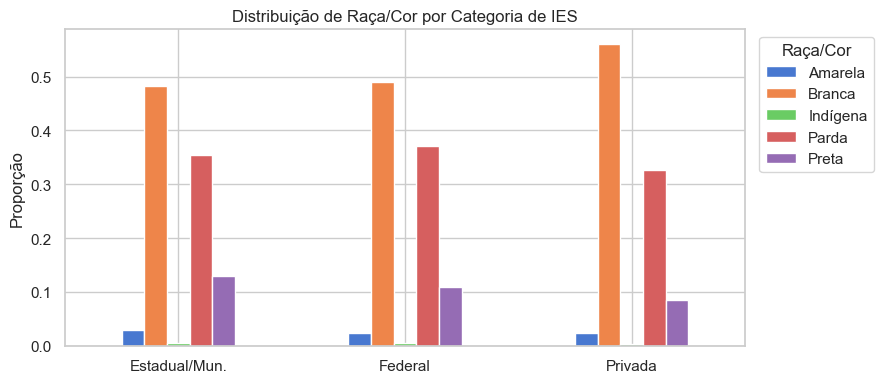

In [64]:
# Raça por categoria de IES
raca_map_orig = {'A':'Branca','B':'Preta','C':'Amarela','D':'Parda','E':'Indígena'}

# Usar df_raw para EDA de raça (antes das dummies)
df_eda = df_raw[df_raw['TP_PRES'] == 555][['CO_CATEGAD','QE_I02']].copy()
df_eda['IES'] = df_eda['CO_CATEGAD'].map({1:'Federal',2:'Estadual/Mun.',
                                           3:'Estadual/Mun.',4:'Privada',5:'Privada'})
df_eda['Raça'] = df_eda['QE_I02'].map(raca_map_orig)
df_eda = df_eda.dropna()

raca_dist = df_eda.groupby('IES')['Raça'].value_counts(normalize=True).unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4))
raca_dist.plot(kind='bar', ax=ax)
ax.set_title('Distribuição de Raça/Cor por Categoria de IES')
ax.set_xlabel('')
ax.set_ylabel('Proporção')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Raça/Cor', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

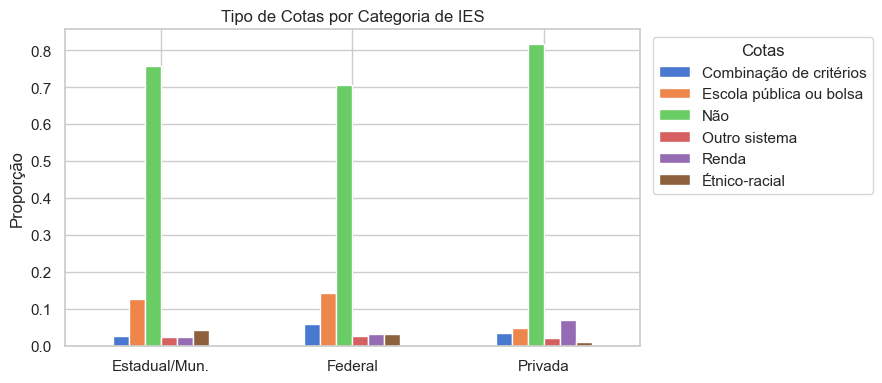

In [71]:
import matplotlib.patches as mpatches

np.random.seed(42)

# Tipo de escola no EM por categoria de IES
cotas = {'A':'Não','B':'Étnico-racial','C':'Renda',
              'D':'Escola pública ou bolsa','E':'Combinação de critérios','F':'Outro sistema'}

df_cotas = df_raw[df_raw['TP_PRES'] == 555][['CO_CATEGAD','QE_I15']].copy()
df_cotas['IES'] = df_cotas['CO_CATEGAD'].map({1:'Federal',2:'Estadual/Mun.',
                                             3:'Estadual/Mun.',4:'Privada',5:'Privada'})
df_cotas['Cotas'] = df_cotas['QE_I15'].map(cotas)
df_cotas = df_cotas.dropna()

cotas_dist = df_cotas.groupby('IES')['Cotas'].value_counts(normalize=True).unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4))
cotas_dist.plot(kind='bar', ax=ax)
ax.set_title('Tipo de Cotas por Categoria de IES')
ax.set_xlabel('')
ax.set_ylabel('Proporção')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Cotas', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

In [90]:
federal = df_cotas[df_cotas['IES'] == 'Federal']
privada = df_cotas[df_cotas['IES'] == 'Privada']


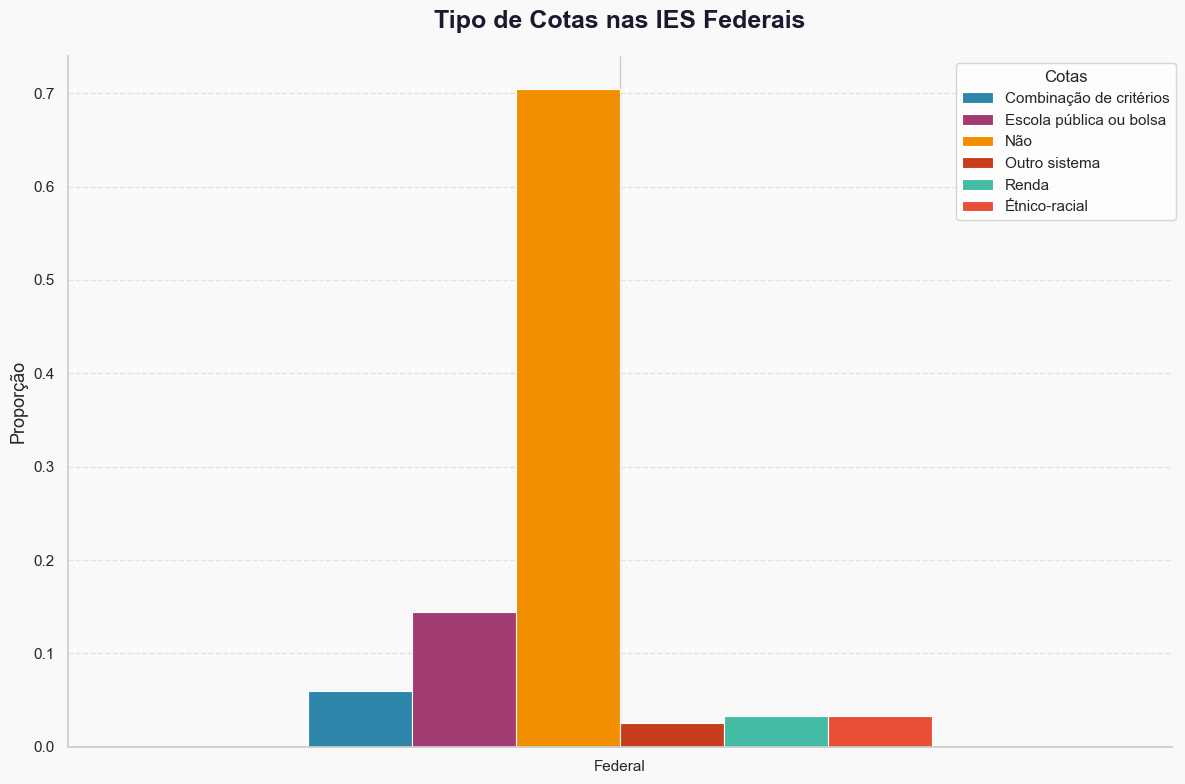

In [96]:
import matplotlib.pyplot as plt
import numpy as np

cores = [
    '#2E86AB',  # azul petróleo
    '#A23B72',  # roxo vinho
    '#F18F01',  # laranja
    '#C73E1D',  # vermelho
    '#44BBA4',  # verde água
    '#E94F37',  # coral
]

federal = df_cotas[df_cotas['IES'] == 'Federal']  # <-- filtro aqui
cotas_dist = federal.groupby('IES')['Cotas'].value_counts(normalize=True).unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 8))
cotas_dist.plot(kind='bar', ax=ax, color=cores[:len(cotas_dist.columns)], edgecolor='white', linewidth=0.8, width=0.65)

ax.set_title('Tipo de Cotas nas IES Federais', fontsize=18, fontweight='bold', pad=20, color='#1a1a2e')
ax.set_xlabel('')
ax.set_ylabel('Proporção', fontsize=13)
ax.tick_params(axis='x', rotation=0, labelsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Cotas', bbox_to_anchor=(1.01, 1))

fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

In [97]:
racial = df_cotas[df_cotas['Cotas'] == 'Étnico-racial']
renda = df_cotas[df_cotas['Cotas'] == 'Renda']

,CO_CATEGAD,QE_I15,IES,Cotas
0,1,A,Federal,Não
1,1,B,Federal,Étnico-racial
2,1,A,Federal,Não
3,1,E,Federal,Combinação de critérios
4,1,A,Federal,Não
...,...,...,...,...
537362,4,A,Privada,Não
537364,3,A,Estadual/Mun.,Não
537376,5,A,Privada,Não
537380,5,A,Privada,Não


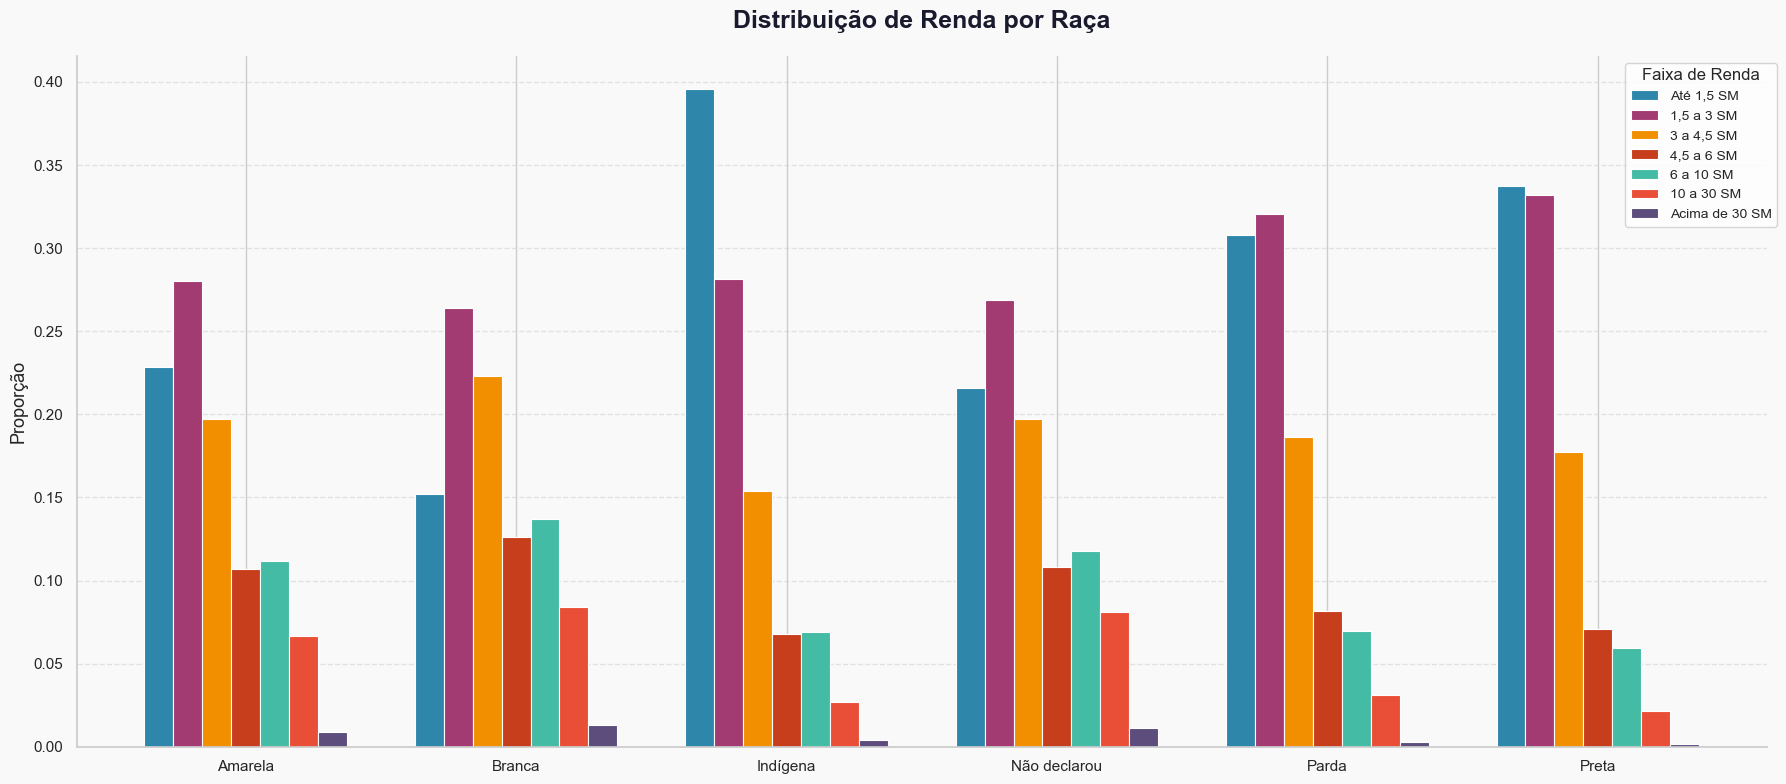

In [99]:
raca_map = {
    'A': 'Branca',
    'B': 'Preta',
    'C': 'Amarela',
    'D': 'Parda',
    'E': 'Indígena',
    'F': 'Não declarou'
}

renda_map = {
    'A': 'Até 1,5 SM',
    'B': '1,5 a 3 SM',
    'C': '3 a 4,5 SM',
    'D': '4,5 a 6 SM',
    'E': '6 a 10 SM',
    'F': '10 a 30 SM',
    'G': 'Acima de 30 SM'
}

df_raca_renda = df_raw[df_raw['TP_PRES'] == 555][['QE_I02', 'QE_I08']].copy()
df_raca_renda['Raça'] = df_raca_renda['QE_I02'].map(raca_map)
df_raca_renda['Renda'] = df_raca_renda['QE_I08'].map(renda_map)
df_raca_renda = df_raca_renda.dropna()

ordem_renda = list(renda_map.values())

dist = (df_raca_renda.groupby('Raça')['Renda']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .reindex(columns=ordem_renda, fill_value=0))

cores = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#44BBA4', '#E94F37', '#5C4D7D']

fig, ax = plt.subplots(figsize=(18, 8))
dist.plot(kind='bar', ax=ax, color=cores[:len(ordem_renda)], edgecolor='white', linewidth=0.8, width=0.75)

ax.set_title('Distribuição de Renda por Raça', fontsize=18, fontweight='bold', pad=20, color='#1a1a2e')
ax.set_xlabel('')
ax.set_ylabel('Proporção', fontsize=13)
ax.tick_params(axis='x', rotation=0, labelsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Faixa de Renda', bbox_to_anchor=(1.01, 1), fontsize=10)

fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

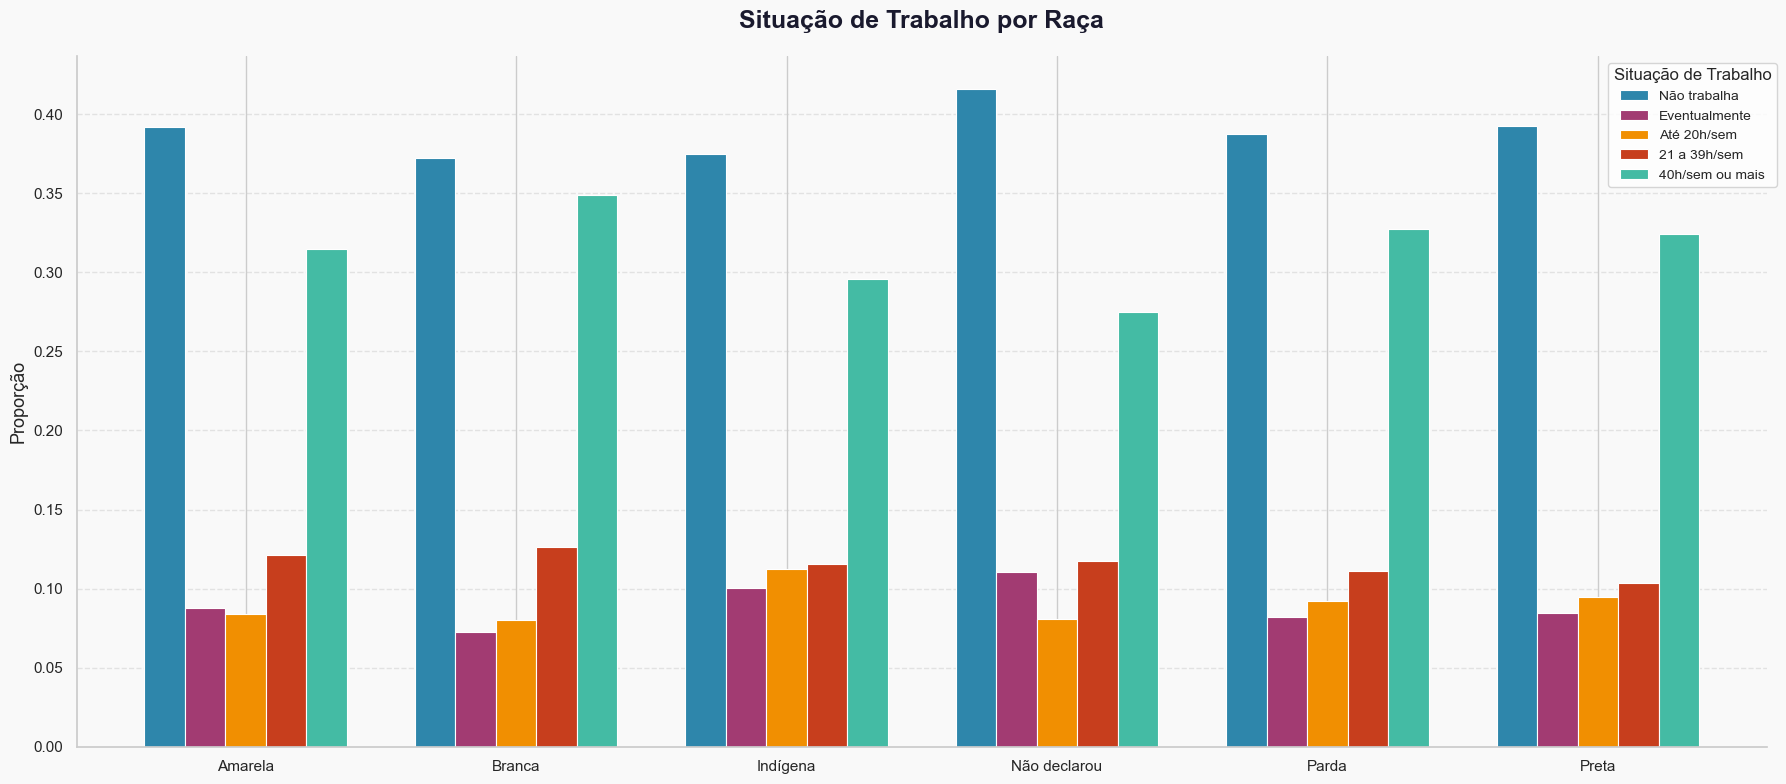

In [100]:
trabalho_map = {
    'A': 'Não trabalha',
    'B': 'Eventualmente',
    'C': 'Até 20h/sem',
    'D': '21 a 39h/sem',
    'E': '40h/sem ou mais'
}

raca_map = {
    'A': 'Branca',
    'B': 'Preta',
    'C': 'Amarela',
    'D': 'Parda',
    'E': 'Indígena',
    'F': 'Não declarou'
}

df_raca_trab = df_raw[df_raw['TP_PRES'] == 555][['QE_I02', 'QE_I10']].copy()
df_raca_trab['Raça'] = df_raca_trab['QE_I02'].map(raca_map)
df_raca_trab['Trabalho'] = df_raca_trab['QE_I10'].map(trabalho_map)
df_raca_trab = df_raca_trab.dropna()

ordem_trabalho = list(trabalho_map.values())

dist = (df_raca_trab.groupby('Raça')['Trabalho']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .reindex(columns=ordem_trabalho, fill_value=0))

cores = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#44BBA4']

fig, ax = plt.subplots(figsize=(18, 8))
dist.plot(kind='bar', ax=ax, color=cores[:len(ordem_trabalho)], edgecolor='white', linewidth=0.8, width=0.75)

ax.set_title('Situação de Trabalho por Raça', fontsize=18, fontweight='bold', pad=20, color='#1a1a2e')
ax.set_xlabel('')
ax.set_ylabel('Proporção', fontsize=13)
ax.tick_params(axis='x', rotation=0, labelsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Situação de Trabalho', bbox_to_anchor=(1.01, 1), fontsize=10)

fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

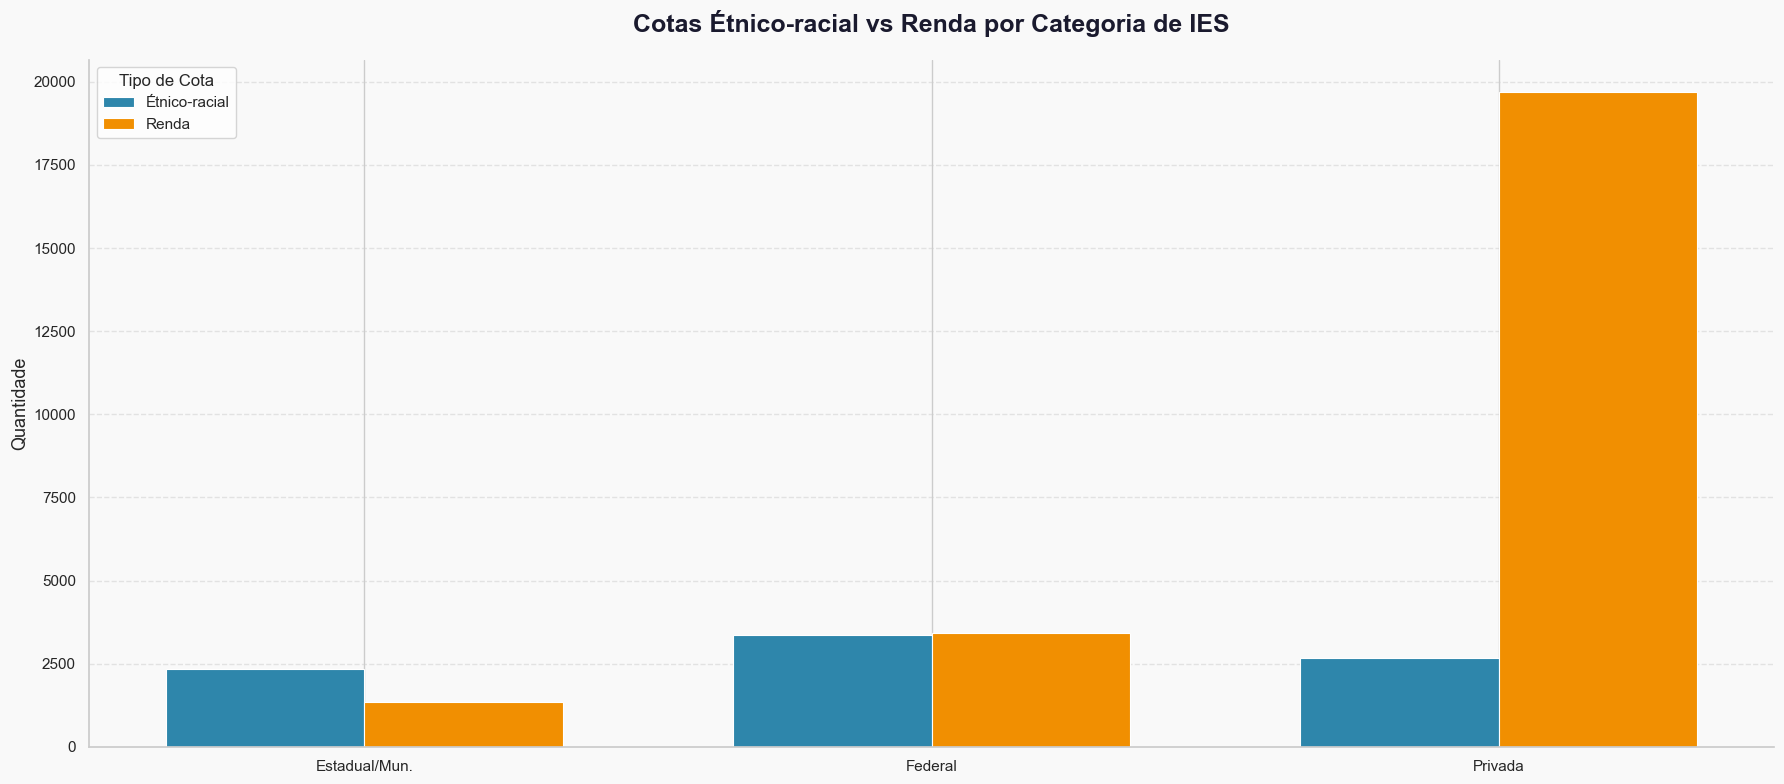

In [98]:
import matplotlib.pyplot as plt
import numpy as np

racial = df_cotas[df_cotas['Cotas'] == 'Étnico-racial']
renda = df_cotas[df_cotas['Cotas'] == 'Renda']

racial_dist = racial['IES'].value_counts()
renda_dist = renda['IES'].value_counts()

categorias = sorted(set(racial_dist.index) | set(renda_dist.index))
racial_vals = [racial_dist.get(c, 0) for c in categorias]
renda_vals = [renda_dist.get(c, 0) for c in categorias]

x = np.arange(len(categorias))
width = 0.35

fig, ax = plt.subplots(figsize=(18, 8))

ax.bar(x - width/2, racial_vals, width, label='Étnico-racial', color='#2E86AB', edgecolor='white', linewidth=0.8)
ax.bar(x + width/2, renda_vals, width, label='Renda', color='#F18F01', edgecolor='white', linewidth=0.8)

ax.set_title('Cotas Étnico-racial vs Renda por Categoria de IES', fontsize=18, fontweight='bold', pad=20, color='#1a1a2e')
ax.set_xlabel('')
ax.set_ylabel('Quantidade', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(categorias, fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Tipo de Cota', fontsize=11)

fig.patch.set_facecolor('#f9f9f9')
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

<Axes: xlabel='IES'>

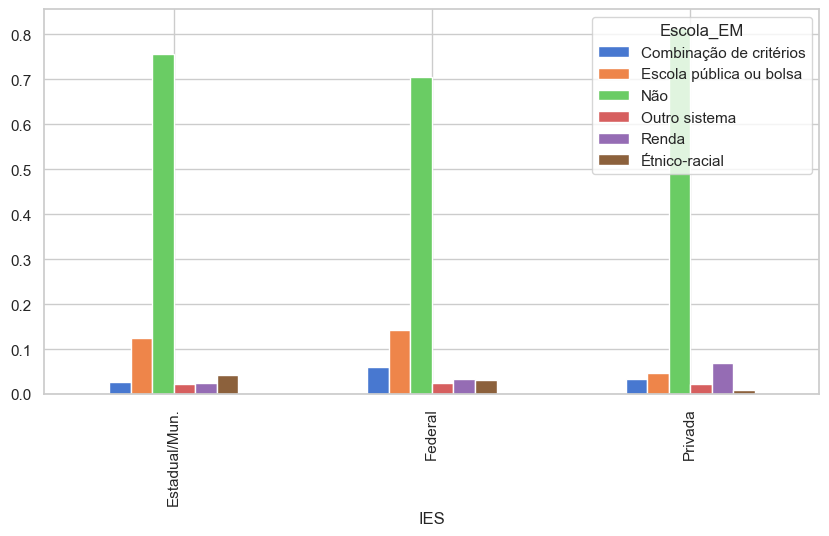

In [70]:
cotas_dist.plot(kind='bar', figsize=(10, 5))

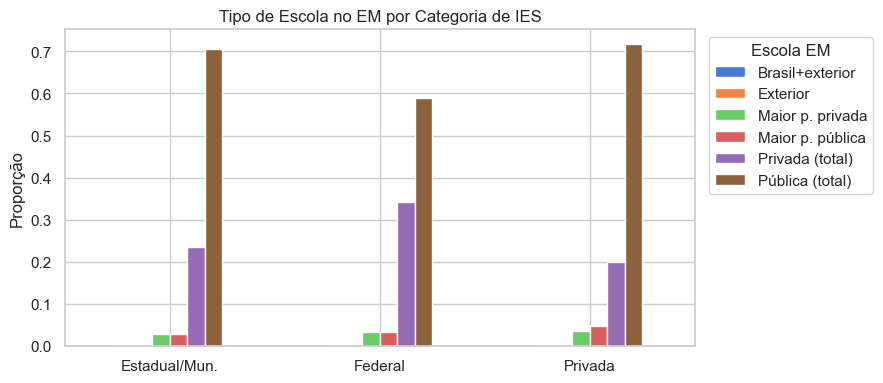

In [65]:
# Tipo de escola no EM por categoria de IES
escola_map = {'A':'Pública (total)','B':'Privada (total)','C':'Exterior',
              'D':'Maior p. pública','E':'Maior p. privada','F':'Brasil+exterior'}

df_eda2 = df_raw[df_raw['TP_PRES'] == 555][['CO_CATEGAD','QE_I17']].copy()
df_eda2['IES'] = df_eda2['CO_CATEGAD'].map({1:'Federal',2:'Estadual/Mun.',
                                             3:'Estadual/Mun.',4:'Privada',5:'Privada'})
df_eda2['Escola_EM'] = df_eda2['QE_I17'].map(escola_map)
df_eda2 = df_eda2.dropna()

escola_dist = df_eda2.groupby('IES')['Escola_EM'].value_counts(normalize=True).unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4))
escola_dist.plot(kind='bar', ax=ax)
ax.set_title('Tipo de Escola no EM por Categoria de IES')
ax.set_xlabel('')
ax.set_ylabel('Proporção')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Escola EM', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

In [67]:
escola_dist

Escola_EM,Brasil+exterior,Exterior,Maior p. privada,Maior p. pública,Privada (total),Pública (total)
IES,,,,,,
Estadual/Mun.,0.0016,0.0008,0.0277,0.0287,0.2353,0.7060
Federal,0.0027,0.0009,0.0329,0.0321,0.3411,0.5904
Privada,0.0019,0.0012,0.0349,0.0467,0.1987,0.7165


---
## 5. Modelagem — Regressão Logística Multinomial

### 5.1 Definição dos Blocos de Variáveis

In [10]:
Y = df['Y'].astype(int)

# Função auxiliar para encontrar colunas que começam com prefixo
def get_dummies_cols(prefix_list, df=df):
    cols = []
    for p in prefix_list:
        cols += [c for c in df.columns if c.startswith(p + '_')]
    return cols

# Bloco 1 — Renda
B1 = ['QE_I08']

# Bloco 2 — Socioeconômico
B2 = get_dummies_cols(['QE_I09']) + ['QE_I10'] + get_dummies_cols(['QE_I11','QE_I12'])

# Bloco 3 — Capital cultural familiar
B3 = ['QE_I04', 'QE_I05', 'QE_I07'] + get_dummies_cols(['QE_I21'])

# Bloco 4 — Perfil individual
B4 = (['NU_IDADE'] +
      get_dummies_cols(['TP_SEXO','QE_I01','QE_I02','QE_I03','QE_I06']))

# Bloco 5 — Trajetória escolar
B5 = (['QE_I22', 'QE_I23'] +
      get_dummies_cols(['QE_I15','QE_I17','QE_I18','QE_I24']))

# Bloco 6 — Motivação e escolha + estratificação
B6 = (get_dummies_cols(['QE_I13','QE_I14','QE_I19','QE_I20','QE_I25','QE_I26']) +
      get_dummies_cols(['CO_REGIAO_CURSO','CO_TURNO_GRADUACAO','CO_MODALIDADE']))

# Verificação
for i, b in enumerate([B1,B2,B3,B4,B5,B6], 1):
    print(f'Bloco {i}: {len(b)} variáveis')

Bloco 1: 1 variáveis
Bloco 2: 21 variáveis
Bloco 3: 4 variáveis
Bloco 4: 18 variáveis
Bloco 5: 20 variáveis
Bloco 6: 49 variáveis


In [55]:
Y

0         1
1         1
2         1
3         1
4         1
         ..
537362    0
537364    2
537376    0
537380    0
537381    1
Name: Y, Length: 441242, dtype: int64

### 5.2 Estimação dos Modelos M1–M6

In [11]:
blocos = {'M1': B1,
          'M2': B1+B2,
          'M3': B1+B2+B3,
          'M4': B1+B2+B3+B4,
          'M5': B1+B2+B3+B4+B5,
          'M6': B1+B2+B3+B4+B5+B6}

resultados = {}
resumo = []

for nome, vars_ in blocos.items():
    # Garante que todas as colunas existem no df
    vars_ok = [v for v in vars_ if v in df.columns]
    X = sm.add_constant(df[vars_ok])
    modelo = MNLogit(Y, X).fit(method='bfgs', maxiter=1000, disp=False)
    resultados[nome] = modelo

    resumo.append({
        'Modelo': nome,
        'N_vars': len(vars_ok),
        'AIC': round(modelo.aic, 1),
        'BIC': round(modelo.bic, 1),
        'Pseudo_R2_McFadden': round(modelo.prsquared, 4),
        'LL': round(modelo.llf, 1)
    })
    print(f"{nome} | Vars: {len(vars_ok):3d} | AIC: {modelo.aic:,.1f} | Pseudo-R²: {modelo.prsquared:.4f}")

df_resumo = pd.DataFrame(resumo)
print()
print(df_resumo.to_string(index=False))

M1 | Vars:   1 | AIC: 777,264.7 | Pseudo-R²: 0.0031
M2 | Vars:  22 | AIC: 278,474.2 | Pseudo-R²: 0.6429
M3 | Vars:  26 | AIC: 277,033.7 | Pseudo-R²: 0.6448
M4 | Vars:  44 | AIC: 273,297.6 | Pseudo-R²: 0.6497
M5 | Vars:  64 | AIC: 265,235.7 | Pseudo-R²: 0.6601
M6 | Vars: 113 | AIC: 233,232.6 | Pseudo-R²: 0.7014

Modelo  N_vars         AIC         BIC  Pseudo_R2_McFadden           LL
    M1       1 777264.7000 777308.7000              0.0031 -388628.3000
    M2      22 278474.2000 278980.1000              0.6429 -139191.1000
    M3      26 277033.7000 277627.5000              0.6448 -138462.8000
    M4      44 273297.6000 274287.4000              0.6497 -136558.8000
    M5      64 265235.7000 266665.3000              0.6601 -132487.8000
    M6     113 233232.6000 235740.0000              0.7014 -116388.3000


### 5.3 Teste de Razão de Verossimilhança entre Modelos Consecutivos

Verifica se cada bloco adicionado melhora significativamente o ajuste.

In [14]:
modelos_list = list(resultados.values())
nomes_list   = list(resultados.keys())

lrt_results = []
for i in range(1, len(modelos_list)):
    m0 = modelos_list[i-1]
    m1 = modelos_list[i]
    stat = -2 * (m0.llf - m1.llf)
    df_diff = m1.df_model - m0.df_model
    p = stats.chi2.sf(stat, df=df_diff)
    lrt_results.append({
        'Comparação': f'{nomes_list[i-1]} → {nomes_list[i]}',
        'ΔLL': round(stat, 2),
        'Δdf': int(df_diff),
        'p-valor': f'{p:.4f}',
        'Sig.': '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    })

pd.DataFrame(lrt_results)

,Comparação,ΔLL,Δdf,p-valor,Sig.
0,M1 → M2,498874.4900,42,0.0000,***
1,M2 → M3,1456.4900,8,0.0000,***
2,M3 → M4,3808.0600,36,0.0000,***
3,M4 → M5,8141.9600,40,0.0000,***
4,M5 → M6,32199.0300,98,0.0000,***


---
## 6. Interpretação dos Resultados

### 6.1 Função auxiliar — Tabela de Odds Ratios

In [46]:
def odds_ratio_table(result, categoria=0, alpha=0.05):
    """
    Retorna tabela de OR com IC e p-valor para uma categoria do modelo.

    categoria=0 → Federal vs Privada
    categoria=1 → Estadual/Municipal vs Privada
    """
    params   = result.params.iloc[:, categoria]
    pvalues  = result.pvalues.iloc[:, categoria]
    conf     = result.conf_int(alpha=alpha)

    ci_lower = conf['lower']
    ci_upper = conf['upper']

    table = pd.DataFrame({
        'OR':      np.exp(params),
        'IC_2.5%': np.exp(ci_lower),
        'IC_97.5%':np.exp(ci_upper),
        'p_valor': pvalues
    })

    table['Sig.'] = table['p_valor'].apply(
        lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    )

    return table.drop(index='const', errors='ignore').sort_values('OR', ascending=False)


print('Função odds_ratio_table() definida.')

Função odds_ratio_table() definida.


### 6.2 Odds Ratios — Federal vs Privada (modelo M6)

In [47]:
or_federal = odds_ratio_table(result=resultados['M6'], categoria=0)

# Filtrar apenas significativos para facilitar leitura
or_federal_sig = or_federal[or_federal['Sig.'] != 'ns']
print(f'Variáveis significativas (Federal vs Privada): {len(or_federal_sig)}')
print()
print(or_federal_sig.round(4).to_string())

Variáveis significativas (Federal vs Privada): 92

                            OR  IC_2.5%  IC_97.5%  p_valor Sig.
QE_I12_E               21.3826      NaN       NaN   0.0000  ***
QE_I12_D               18.1061      NaN       NaN   0.0000  ***
QE_I12_C               14.4576      NaN       NaN   0.0000  ***
QE_I12_B               12.4040      NaN       NaN   0.0000  ***
QE_I13_E               10.9439      NaN       NaN   0.0000  ***
QE_I13_C                6.2381      NaN       NaN   0.0000  ***
QE_I25_G                5.9164      NaN       NaN   0.0000  ***
CO_TURNO_GRADUACAO_3.0  5.2746      NaN       NaN   0.0000  ***
QE_I13_B                4.4875      NaN       NaN   0.0000  ***
QE_I13_D                4.2070      NaN       NaN   0.0000  ***
CO_MODALIDADE_1         3.7388      NaN       NaN   0.0000  ***
QE_I15_B                3.4786      NaN       NaN   0.0000  ***
QE_I12_F                3.3379      NaN       NaN   0.0000  ***
QE_I13_F                2.8244      NaN       NaN   0

### 6.3 Odds Ratios — Estadual/Municipal vs Privada (modelo M6)

In [48]:
or_estadual = odds_ratio_table(resultados['M6'], categoria=1)
or_estadual_sig = or_estadual[or_estadual['Sig.'] != 'ns']

print(f'Variáveis significativas (Estadual/Mun. vs Privada): {len(or_estadual_sig)}')
print()
print(or_estadual_sig.round(4).to_string())

Variáveis significativas (Estadual/Mun. vs Privada): 84

                           OR  IC_2.5%  IC_97.5%  p_valor Sig.
CO_MODALIDADE_1        7.4949      NaN       NaN   0.0000  ***
QE_I12_E               7.1213      NaN       NaN   0.0000  ***
QE_I13_C               4.8582      NaN       NaN   0.0000  ***
QE_I13_E               4.0656      NaN       NaN   0.0000  ***
QE_I25_G               3.8995      NaN       NaN   0.0000  ***
QE_I12_B               3.5146      NaN       NaN   0.0000  ***
QE_I12_D               3.4762      NaN       NaN   0.0000  ***
QE_I15_B               3.3986      NaN       NaN   0.0000  ***
QE_I13_B               3.2815      NaN       NaN   0.0000  ***
QE_I12_C               2.7875      NaN       NaN   0.0000  ***
QE_I06_E               2.3948      NaN       NaN   0.0000  ***
QE_I25_F               2.3652      NaN       NaN   0.0000  ***
CO_REGIAO_CURSO_2      2.3369      NaN       NaN   0.0000  ***
CO_TURNO_GRADUACAO_3.0 2.2909      NaN       NaN   0.0000  **

### 6.4 Visualização — Forest Plot dos OR (Federal vs Privada)

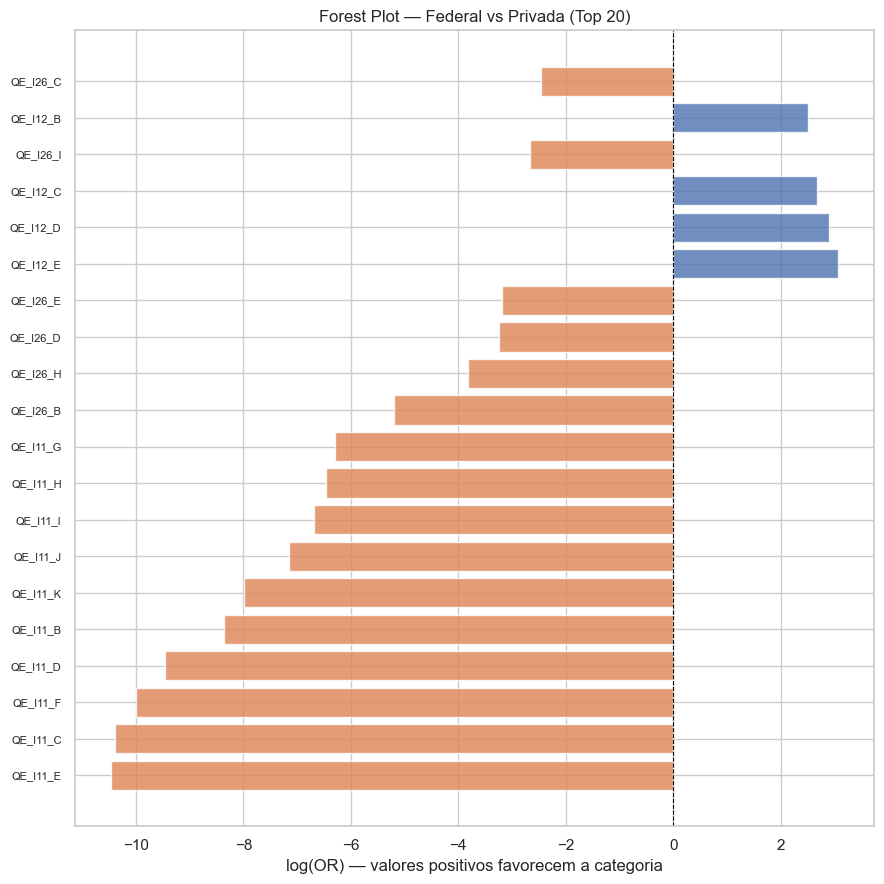

In [49]:
def forest_plot(or_table, title, top_n=20):
    """
    Forest plot das top_n variáveis mais extremas por OR.
    """
    sig = or_table[or_table['Sig.'] != 'ns'].copy()

    # Top N mais distantes de 1
    sig['dist_1'] = abs(np.log(sig['OR']))
    sig = sig.nlargest(top_n, 'dist_1')

    fig, ax = plt.subplots(figsize=(9, len(sig) * 0.4 + 1))

    colors = ['#DD8452' if or_ < 1 else '#4C72B0' for or_ in sig['OR']]

    ax.barh(range(len(sig)), np.log(sig['OR']), color=colors, alpha=0.8)
    ax.errorbar(
        np.log(sig['OR']),
        range(len(sig)),
        xerr=[np.log(sig['OR']) - np.log(sig['IC_2.5%']),
              np.log(sig['IC_97.5%']) - np.log(sig['OR'])],
        fmt='none', color='black', capsize=3, linewidth=1
    )

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(range(len(sig)))
    ax.set_yticklabels(sig.index, fontsize=8)
    ax.set_xlabel('log(OR) — valores positivos favorecem a categoria')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


forest_plot(or_federal, title='Forest Plot — Federal vs Privada (Top 20)')

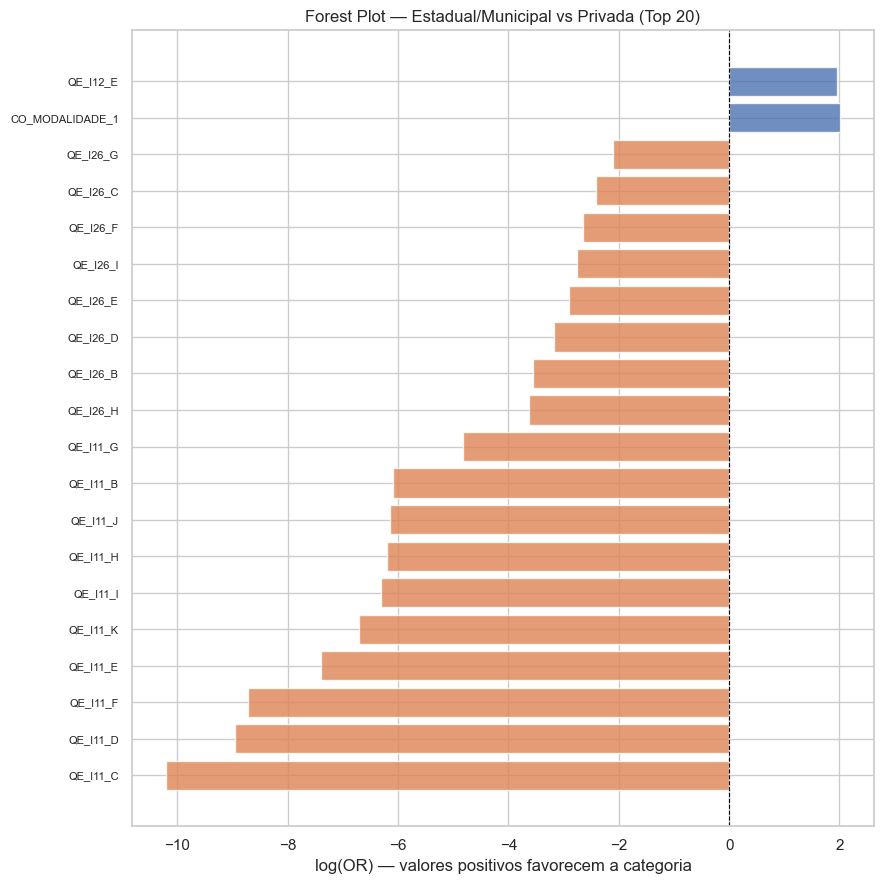

In [50]:
forest_plot(or_estadual, title='Forest Plot — Estadual/Municipal vs Privada (Top 20)')

### 6.5 Evolução do Pseudo-R² por Bloco

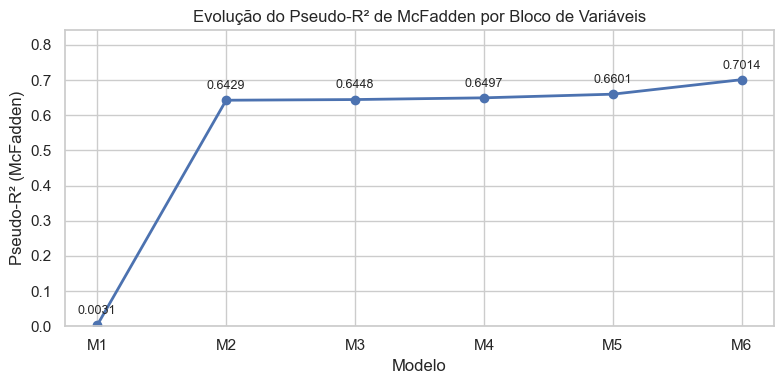

In [51]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df_resumo['Modelo'], df_resumo['Pseudo_R2_McFadden'],
        marker='o', linewidth=2, color='#4C72B0')

for _, row in df_resumo.iterrows():
    ax.annotate(f"{row['Pseudo_R2_McFadden']:.4f}",
                (row['Modelo'], row['Pseudo_R2_McFadden']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

ax.set_title('Evolução do Pseudo-R² de McFadden por Bloco de Variáveis')
ax.set_xlabel('Modelo')
ax.set_ylabel('Pseudo-R² (McFadden)')
ax.set_ylim(0, df_resumo['Pseudo_R2_McFadden'].max() * 1.2)
plt.tight_layout()
plt.show()

---
## 7. Análise por Subgrupos

### 7.1 OR da Renda por Região

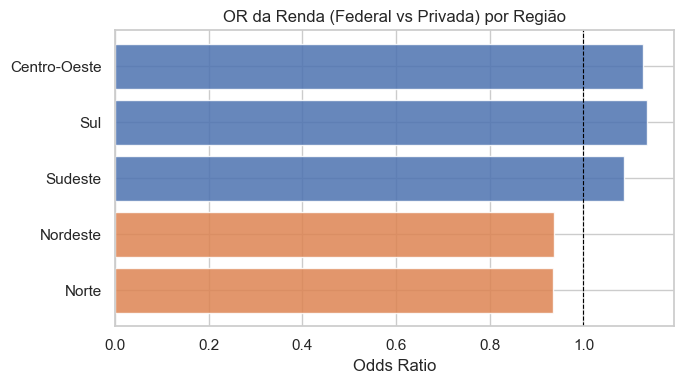

Norte          0.9345
Nordeste       0.9377
Sudeste        1.0870
Sul            1.1364
Centro-Oeste   1.1262
Name: OR_Renda, dtype: float64


In [52]:
regioes = {1: 'Norte', 2: 'Nordeste', 3: 'Sudeste', 4: 'Sul', 5: 'Centro-Oeste'}
or_renda_regiao = {}

for cod, nome in regioes.items():
    mask = df_raw[df_raw['TP_PRES'] == 555]['CO_REGIAO_CURSO'] == cod
    idx  = df_raw[df_raw['TP_PRES'] == 555][mask].index
    df_r = df.loc[df.index.intersection(idx)]

    if len(df_r) < 500:
        continue

    Y_r = df_r['Y'].astype(int)
    X_r = sm.add_constant(df_r[B1 + B3])  # renda + capital cultural
    try:
        m = MNLogit(Y_r, X_r).fit(method='bfgs', maxiter=500, disp=False)
        or_val = np.exp(m.params.loc['QE_I08', 0])
        or_renda_regiao[nome] = or_val
    except Exception:
        pass

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
regioes_names = list(or_renda_regiao.keys())
or_vals = list(or_renda_regiao.values())
colors  = ['#4C72B0' if v > 1 else '#DD8452' for v in or_vals]

ax.barh(regioes_names, or_vals, color=colors, alpha=0.85)
ax.axvline(1, color='black', linewidth=0.8, linestyle='--')
ax.set_title('OR da Renda (Federal vs Privada) por Região')
ax.set_xlabel('Odds Ratio')
plt.tight_layout()
plt.show()

print(pd.Series(or_renda_regiao, name='OR_Renda').round(4))

### 7.2 Sumário do Modelo Final

In [53]:
print(resultados['M6'].summary())

                          MNLogit Regression Results                          
Dep. Variable:                      Y   No. Observations:               441242
Model:                        MNLogit   Df Residuals:                   441014
Method:                           MLE   Df Model:                          226
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                  0.7014
Time:                        00:06:01   Log-Likelihood:            -1.1639e+05
converged:                       True   LL-Null:                   -3.8982e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   Y=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      4.5988      0.144     31.977      0.000       4.317       4.881
QE_I08                    -0.0123      0.010     -1.260      0.208      -0.031       0.007
QE_I

---
## 8. Conclusões

> Após a estimação dos modelos M1–M6 e análise dos odds ratios, registre aqui os principais achados:
>
> - **H1 (Renda):** ...
> - **H2 (Raça):** ...
> - **H3 (Capital cultural):** ...
> - **H4 (Escola EM):** ...
> - **H5 (Cotas):** ...
> - **H6 (Região):** ...